# Comparison of Experiments A and B — configuration scaling, exact certification, and computational effort

This notebook compares the completed paper runs:

- **Experiment A:** 4 helicopters × 4 demand areas, exact budget up to 600 s.
- **Experiment B:** 6 helicopters × 7 demand areas, exact budget up to 1800 s.

It **does not rerun Greedy or HiGHS**. It reads the final metrics CSV files and produces paper-ready comparative figures, audit tables, and machine-readable summaries.

## Interpretation boundary

The comparison estimates the **joint effect of changing the configuration from 4×4 to 6×7**. It does not separately identify the effect of adding helicopters and the effect of adding demand areas. Direct budget comparisons use only the common budgets `1, 5, 15, 60, 600` s. The 1800 s observations are displayed as a B-only extension.

In [14]:
# ============================================================
# 01. IMPORTS, PATHS, AND GLOBAL CONFIGURATION
# ============================================================
import json
import os
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter

try:
    from IPython.display import display
except ImportError:
    display = print

EXPERIMENT_A_RELATIVE = Path(
    "ttap_experiment_A_4x4_impact_anytime_traced"
) / "metrics_A4x4_paper_20260808_112401-0400_matched_v3_impact_anytime.csv"

EXPERIMENT_B_RELATIVE = Path(
    "ttap_experiment_B_6x7_stress_impact_anytime_traced"
) / "metrics_B6x7_stress_paper_20260825_195505-0400_matched_v3_impact_anytime_old6x7_operational_config.csv"

EXPECTED_TASKS = [20, 30, 40, 50, 60]
EXPECTED_SEEDS = list(range(1, 31))
EXPECTED_A_BUDGETS = [1, 5, 15, 60, 600]
EXPECTED_B_BUDGETS = [1, 5, 15, 60, 600, 1800]
COMMON_BUDGETS = sorted(set(EXPECTED_A_BUDGETS) & set(EXPECTED_B_BUDGETS))

CONFIG_A = "A: 4 helos × 4 areas"
CONFIG_B = "B: 6 helos × 7 areas"
CONFIG_ORDER = [CONFIG_A, CONFIG_B]

COLOR_A = "#0072B2"
COLOR_B = "#D55E00"
COLOR_NEUTRAL = "#4D4D4D"
CONFIG_COLORS = {CONFIG_A: COLOR_A, CONFIG_B: COLOR_B}
CONFIG_MARKERS = {CONFIG_A: "o", CONFIG_B: "s"}
CONFIG_LINESTYLES = {CONFIG_A: "-", CONFIG_B: "--"}

# 600 dpi is a high-resolution and memory-safe default for the large
# composite figure; the PDF export remains vector. If 2000 dpi is
# explicitly required and sufficient RAM is available, set
# TTAP_EXPORT_DPI=2000 before execution.
EXPORT_DPI = int(os.getenv("TTAP_EXPORT_DPI", "600"))


def resolve_metrics_path(relative_path):
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / relative_path,
        cwd / "Resuelto_Paper" / relative_path,
        cwd.parent / relative_path,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    attempted = "\n".join(f"  - {p}" for p in candidates)
    raise FileNotFoundError(
        f"Could not locate {relative_path.name}. Attempted:\n{attempted}"
    )


A_CSV = resolve_metrics_path(EXPERIMENT_A_RELATIVE)
B_CSV = resolve_metrics_path(EXPERIMENT_B_RELATIVE)
PAPER_DIR = A_CSV.parent.parent
OUTPUT_ROOT = PAPER_DIR / "ttap_comparison_A4x4_B6x7"
FIGURE_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Computational environment")
print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", mpl.__version__)
print("Experiment A metrics:", A_CSV)
print("Experiment B metrics:", B_CSV)
print("Output root:", OUTPUT_ROOT)
print("PNG export DPI:", EXPORT_DPI)

Computational environment
Python: 3.11.3
Platform: macOS-26.6.2-arm64-arm-64bit
NumPy: 2.4.6
Pandas: 3.0.5
Matplotlib: 3.11.1
Experiment A metrics: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_experiment_A_4x4_impact_anytime_traced/metrics_A4x4_paper_20260808_112401-0400_matched_v3_impact_anytime.csv
Experiment B metrics: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_experiment_B_6x7_stress_impact_anytime_traced/metrics_B6x7_stress_paper_20260825_195505-0400_matched_v3_impact_anytime_old6x7_operational_config.csv
Output root: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7
PNG export DPI: 600


In [15]:
# ============================================================
# 02. DATA LOADING, NORMALIZATION, AND STRICT VALIDATION
# ============================================================
REQUIRED_COLUMNS = {
    "Execution ID", "Scenario", "Seed", "Tasks", "Method",
    "Solver Time sec", "End-to-end sec", "Optimal Certified",
    "Variables", "Constraints", "Nonzeros", "Time Limit sec",
}


def normalize_boolean(series):
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    normalized = series.astype(str).str.strip().str.lower()
    return normalized.isin({"true", "1", "yes", "y"})


def load_experiment(path, configuration):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    missing = REQUIRED_COLUMNS.difference(df.columns)
    if missing:
        raise AssertionError(
            f"{configuration}: missing required columns {sorted(missing)}"
        )

    numeric_columns = [
        "Seed", "Tasks", "Solver Time sec", "End-to-end sec",
        "Variables", "Constraints", "Nonzeros", "Time Limit sec",
    ]
    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df["Optimal Certified"] = normalize_boolean(df["Optimal Certified"])
    if "Has Incumbent" in df.columns:
        df["Has Incumbent"] = normalize_boolean(df["Has Incumbent"])
    if "Has Positive Plan" in df.columns:
        df["Has Positive Plan"] = normalize_boolean(df["Has Positive Plan"])

    df["Configuration"] = configuration
    return df


data_a = load_experiment(A_CSV, CONFIG_A)
data_b = load_experiment(B_CSV, CONFIG_B)
metrics = pd.concat([data_a, data_b], ignore_index=True, sort=False)

highs = metrics[
    metrics["Method"].astype(str).str.startswith("HiGHS-")
].copy()
highs = highs.dropna(subset=["Tasks", "Seed", "Time Limit sec"])
highs["Tasks"] = highs["Tasks"].astype(int)
highs["Seed"] = highs["Seed"].astype(int)
highs["Budget sec"] = highs["Time Limit sec"].astype(float)


def validate_configuration(df, configuration, expected_budgets):
    subset = df[df["Configuration"] == configuration].copy()
    task_values = sorted(subset["Tasks"].unique().tolist())
    seed_values = sorted(subset["Seed"].unique().tolist())
    budget_values = sorted(subset["Budget sec"].unique().tolist())

    assert task_values == EXPECTED_TASKS, (
        configuration, "unexpected task counts", task_values
    )
    assert seed_values == EXPECTED_SEEDS, (
        configuration, "unexpected seeds", seed_values
    )
    assert budget_values == [float(x) for x in expected_budgets], (
        configuration, "unexpected budgets", budget_values
    )

    counts = subset.groupby(
        ["Tasks", "Seed", "Budget sec"], observed=True
    ).size()
    assert counts.eq(1).all(), (
        configuration,
        "each (Tasks, Seed, Budget) combination must appear exactly once",
    )
    expected_rows = (
        len(EXPECTED_TASKS) * len(EXPECTED_SEEDS) * len(expected_budgets)
    )
    assert len(subset) == expected_rows, (
        configuration, len(subset), expected_rows
    )


validate_configuration(highs, CONFIG_A, EXPECTED_A_BUDGETS)
validate_configuration(highs, CONFIG_B, EXPECTED_B_BUDGETS)

audit = (
    highs.groupby("Configuration", observed=True)
    .agg(
        HiGHS_rows=("Method", "size"),
        Scenarios=("Scenario", "nunique"),
        Seeds=("Seed", "nunique"),
        Min_tasks=("Tasks", "min"),
        Max_tasks=("Tasks", "max"),
        Min_budget=("Budget sec", "min"),
        Max_budget=("Budget sec", "max"),
    )
    .reindex(CONFIG_ORDER)
)
display(audit)
print("Strict A–B dataset validation completed successfully.")

,HiGHS_rows,Scenarios,Seeds,Min_tasks,Max_tasks,Min_budget,Max_budget
Configuration,,,,,,,
A: 4 helos × 4 areas,750,150,30,20,60,1.0,600.0
B: 6 helos × 7 areas,900,150,30,20,60,1.0,1800.0


Strict A–B dataset validation completed successfully.


In [16]:
# ============================================================
# 03. PAPER GRAPHICAL STANDARD AND EXPORT HELPERS
# ============================================================
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9.5,
    "axes.titlesize": 10.5,
    "axes.labelsize": 10,
    "axes.titleweight": "semibold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5,
    "figure.titlesize": 12,
    "figure.titleweight": "semibold",
    "lines.linewidth": 1.8,
    "lines.markersize": 5.5,
    "savefig.transparent": False,
    "savefig.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def save_figure(fig, stem):
    png_path = FIGURE_DIR / f"{stem}.png"
    pdf_path = FIGURE_DIR / f"{stem}.pdf"
    fig.savefig(
        png_path,
        dpi=EXPORT_DPI,
        bbox_inches="tight",
        facecolor="white",
    )
    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        facecolor="white",
    )
    print("PNG saved at:", png_path)
    print("PDF saved at:", pdf_path)
    return png_path, pdf_path


print("Paper graphical standard configured.")

Paper graphical standard configured.


## Comparative data products

Certification is computed independently for each configuration, task count, and time budget. Pairing is enforced by the common `(Tasks, Seed)` structure. No averaging across different task counts is used in the main budget figure.

In [17]:
# ============================================================
# 04. CERTIFICATION TABLES, COMMON-BUDGET AUDIT, AND THRESHOLDS
# ============================================================
certification = (
    highs.groupby(
        ["Configuration", "Tasks", "Budget sec"], observed=True
    )
    .agg(
        Instances=("Seed", "nunique"),
        Certified=("Optimal Certified", "sum"),
    )
    .reset_index()
)
certification["Certification Rate"] = (
    certification["Certified"] / certification["Instances"]
)
certification["Certification Percent"] = (
    100.0 * certification["Certification Rate"]
)

# Regression checks against the completed paper runs.
expected_counts = {
    (CONFIG_A, 600): {20: 30, 30: 30, 40: 30, 50: 30, 60: 30},
    (CONFIG_B, 600): {20: 30, 30: 28, 40: 20, 50: 7, 60: 1},
    (CONFIG_B, 1800): {20: 30, 30: 30, 40: 27, 50: 21, 60: 9},
}
for (configuration, budget), expected in expected_counts.items():
    observed = (
        certification[
            (certification["Configuration"] == configuration)
            & (certification["Budget sec"] == float(budget))
        ]
        .set_index("Tasks")["Certified"]
        .astype(int)
        .to_dict()
    )
    assert observed == expected, (
        configuration, budget, observed, expected
    )

common_certification = certification[
    certification["Budget sec"].isin(COMMON_BUDGETS)
].copy()
common_pivot = common_certification.pivot(
    index=["Tasks", "Budget sec"],
    columns="Configuration",
    values="Certification Percent",
).reset_index()
common_pivot["B minus A pp"] = (
    common_pivot[CONFIG_B] - common_pivot[CONFIG_A]
)


def first_tested_budget(configuration, tasks, target_percent):
    rows = certification[
        (certification["Configuration"] == configuration)
        & (certification["Tasks"] == tasks)
    ].sort_values("Budget sec")
    reached = rows[
        rows["Certification Percent"] >= float(target_percent)
    ]
    if reached.empty:
        return np.nan
    return float(reached.iloc[0]["Budget sec"])


threshold_rows = []
for target in [80, 95]:
    for tasks in EXPECTED_TASKS:
        for configuration in CONFIG_ORDER:
            tested_max = (
                max(EXPECTED_A_BUDGETS)
                if configuration == CONFIG_A
                else max(EXPECTED_B_BUDGETS)
            )
            required = first_tested_budget(
                configuration, tasks, target
            )
            threshold_rows.append({
                "Target Percent": target,
                "Tasks": tasks,
                "Configuration": configuration,
                "First Tested Budget sec": required,
                "Right Censored": pd.isna(required),
                "Maximum Tested Budget sec": tested_max,
            })
budget_thresholds = pd.DataFrame(threshold_rows)

certification.to_csv(
    TABLE_DIR / "AB_certification_rates.csv", index=False
)
common_pivot.to_csv(
    TABLE_DIR / "AB_common_budget_certification_differences.csv",
    index=False,
)
budget_thresholds.to_csv(
    TABLE_DIR / "AB_budget_thresholds.csv", index=False
)

display(certification)
display(common_pivot)
display(budget_thresholds)
print("Certification tables validated and exported.")

,Configuration,Tasks,Budget sec,Instances,Certified,Certification Rate,Certification Percent
0,A: 4 helos × 4 areas,20,1.0,30,2,0.066667,6.666667
1,A: 4 helos × 4 areas,20,5.0,30,22,0.733333,73.333333
2,A: 4 helos × 4 areas,20,15.0,30,29,0.966667,96.666667
3,A: 4 helos × 4 areas,20,60.0,30,30,1.000000,100.000000
4,A: 4 helos × 4 areas,20,600.0,30,30,1.000000,100.000000
5,A: 4 helos × 4 areas,30,1.0,30,0,0.000000,0.000000
6,A: 4 helos × 4 areas,30,5.0,30,9,0.300000,30.000000
7,A: 4 helos × 4 areas,30,15.0,30,27,0.900000,90.000000
8,A: 4 helos × 4 areas,30,60.0,30,30,1.000000,100.000000
9,A: 4 helos × 4 areas,30,600.0,30,30,1.000000,100.000000


Configuration,Tasks,Budget sec,A: 4 helos × 4 areas,B: 6 helos × 7 areas,B minus A pp
0,20,1.0,6.666667,0.000000,-6.666667
1,20,5.0,73.333333,3.333333,-70.000000
2,20,15.0,96.666667,40.000000,-56.666667
3,20,60.0,100.000000,83.333333,-16.666667
4,20,600.0,100.000000,100.000000,0.000000
5,30,1.0,0.000000,0.000000,0.000000
6,30,5.0,30.000000,0.000000,-30.000000
7,30,15.0,90.000000,6.666667,-83.333333
8,30,60.0,100.000000,33.333333,-66.666667
9,30,600.0,100.000000,93.333333,-6.666667


,Target Percent,Tasks,Configuration,First Tested Budget sec,Right Censored,Maximum Tested Budget sec
0,80,20,A: 4 helos × 4 areas,15.0,False,600
1,80,20,B: 6 helos × 7 areas,60.0,False,1800
2,80,30,A: 4 helos × 4 areas,15.0,False,600
3,80,30,B: 6 helos × 7 areas,600.0,False,1800
4,80,40,A: 4 helos × 4 areas,60.0,False,600
5,80,40,B: 6 helos × 7 areas,1800.0,False,1800
6,80,50,A: 4 helos × 4 areas,60.0,False,600
7,80,50,B: 6 helos × 7 areas,NaN,True,1800
8,80,60,A: 4 helos × 4 areas,600.0,False,600
9,80,60,B: 6 helos × 7 areas,NaN,True,1800


Certification tables validated and exported.


PNG saved at: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/figures/AB1_certification_frontiers.png
PDF saved at: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/figures/AB1_certification_frontiers.pdf


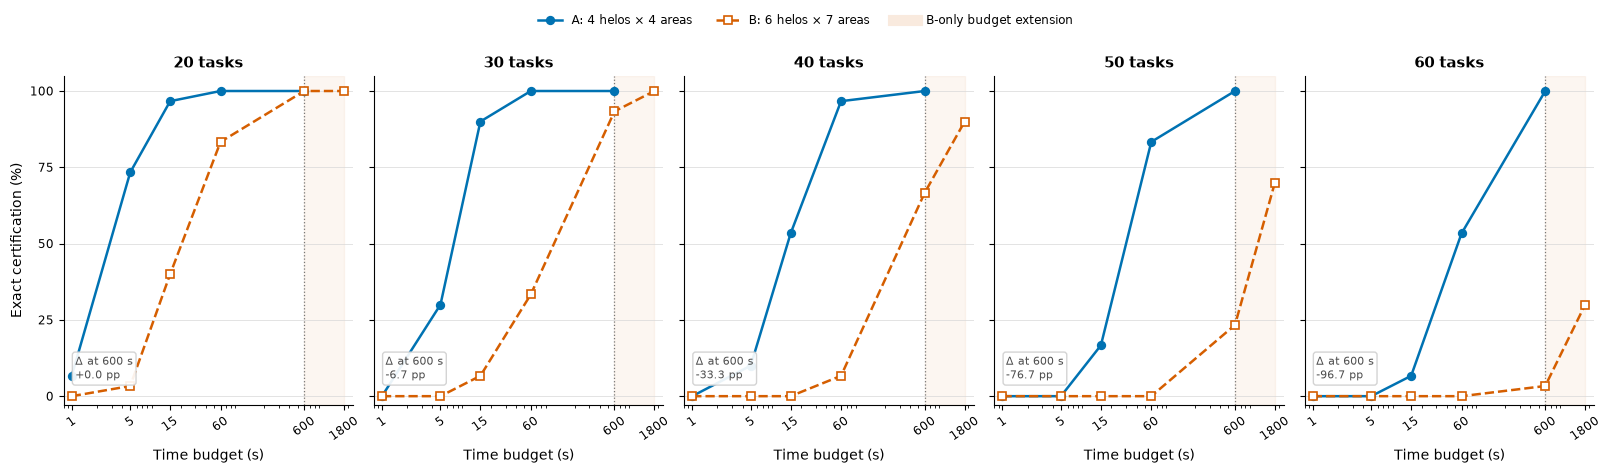

In [18]:
# ============================================================
# AB1 — EXACT-CERTIFICATION FRONTIERS BY TASK COUNT
# ============================================================
fig, top_axes = plt.subplots(
    1,
    len(EXPECTED_TASKS),
    figsize=(16.0, 4.15),
    sharey=True,
    constrained_layout=True,
)

all_budget_ticks = [1, 5, 15, 60, 600, 1800]

for index, (ax, tasks) in enumerate(zip(top_axes, EXPECTED_TASKS)):

    for configuration in CONFIG_ORDER:
        rows = certification[
            (certification["Configuration"] == configuration)
            & (certification["Tasks"] == tasks)
        ].sort_values("Budget sec")

        ax.plot(
            rows["Budget sec"],
            rows["Certification Percent"],
            color=CONFIG_COLORS[configuration],
            marker=CONFIG_MARKERS[configuration],
            linestyle=CONFIG_LINESTYLES[configuration],
            markerfacecolor=(
                "white"
                if configuration == CONFIG_B
                else CONFIG_COLORS[configuration]
            ),
            markeredgewidth=1.2,
            label=configuration,
            zorder=3,
        )

    # Difference between configurations at the common 600 s budget
    delta_600 = common_pivot.loc[
        (common_pivot["Tasks"] == tasks)
        & (common_pivot["Budget sec"] == 600),
        "B minus A pp",
    ].iloc[0]

    # Region available only for Experiment B
    ax.axvspan(
        600,
        1800,
        color=COLOR_B,
        alpha=0.055,
        zorder=0,
    )

    # Maximum common budget
    ax.axvline(
        600,
        color="#777777",
        linewidth=0.9,
        linestyle=":",
    )

    ax.text(
        0.04,
        0.07,
        f"Δ at 600 s\n{delta_600:+.1f} pp",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8.2,
        color=COLOR_NEUTRAL,
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "#D0D0D0",
            "alpha": 0.92,
        },
    )

    ax.set_xscale("log")
    ax.set_xlim(0.8, 2300)
    ax.set_ylim(-3, 105)

    ax.set_xticks(all_budget_ticks)
    ax.set_xticklabels(
        [str(value) for value in all_budget_ticks],
        rotation=35,
    )

    ax.set_yticks([0, 25, 50, 75, 100])

    ax.grid(
        True,
        axis="y",
        color="#D9D9D9",
        linewidth=0.7,
        alpha=0.75,
    )

    ax.set_title(f"{tasks} tasks")
    ax.set_xlabel("Time budget (s)")

    if index == 0:
        ax.set_ylabel("Exact certification (%)")
    else:
        ax.tick_params(labelleft=False)


# Shared legend
handles = [
    Line2D(
        [0],
        [0],
        color=CONFIG_COLORS[configuration],
        marker=CONFIG_MARKERS[configuration],
        linestyle=CONFIG_LINESTYLES[configuration],
        markerfacecolor=(
            "white"
            if configuration == CONFIG_B
            else CONFIG_COLORS[configuration]
        ),
        markeredgewidth=1.2,
        label=configuration,
    )
    for configuration in CONFIG_ORDER
]

handles.append(
    Line2D(
        [0],
        [0],
        color=COLOR_B,
        linewidth=8,
        alpha=0.13,
        label="B-only budget extension",
    )
)

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.035),
)

#fig.suptitle("Configuration scaling shifts the exact-certification frontier", y=1.075,)

save_figure(
    fig,
    "AB1_certification_frontiers",
)

plt.show()

PNG saved at: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/figures/AB2_common_budget_certification_loss_heatmap.png
PDF saved at: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/figures/AB2_common_budget_certification_loss_heatmap.pdf


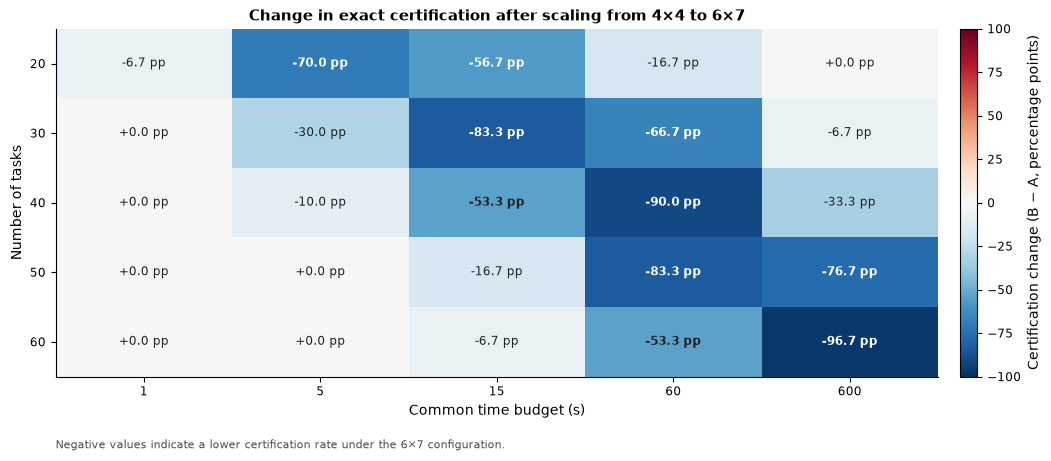

Budget sec,1,5,15,60,600
Tasks,,,,,
20,-6.666667,-70.0,-56.666667,-16.666667,0.000000
30,0.000000,-30.0,-83.333333,-66.666667,-6.666667
40,0.000000,-10.0,-53.333333,-90.000000,-33.333333
50,0.000000,0.0,-16.666667,-83.333333,-76.666667
60,0.000000,0.0,-6.666667,-53.333333,-96.666667


In [19]:
# ============================================================
# AB2 — COMMON-BUDGET CERTIFICATION LOSS HEATMAP
# ============================================================
delta_matrix = (
    common_pivot.pivot(
        index="Tasks", columns="Budget sec", values="B minus A pp"
    )
    .reindex(index=EXPECTED_TASKS, columns=COMMON_BUDGETS)
)

fig, ax = plt.subplots(figsize=(10.4, 4.5), constrained_layout=True)
image = ax.imshow(
    delta_matrix.to_numpy(),
    cmap="RdBu_r",
    vmin=-100,
    vmax=100,
    aspect="auto",
)

ax.set_xticks(np.arange(len(COMMON_BUDGETS)))
ax.set_xticklabels([str(x) for x in COMMON_BUDGETS])
ax.set_yticks(np.arange(len(EXPECTED_TASKS)))
ax.set_yticklabels([str(x) for x in EXPECTED_TASKS])
ax.set_xlabel("Common time budget (s)")
ax.set_ylabel("Number of tasks")
ax.set_title(
    "Change in exact certification after scaling from 4×4 to 6×7"
)

for row in range(delta_matrix.shape[0]):
    for col in range(delta_matrix.shape[1]):
        value = float(delta_matrix.iloc[row, col])
        text_color = "white" if abs(value) >= 55 else "#222222"
        ax.text(
            col, row, f"{value:+.1f} pp",
            ha="center", va="center",
            fontsize=8.5,
            color=text_color,
            fontweight="semibold" if abs(value) >= 50 else "normal",
        )

colorbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.025)
colorbar.set_label("Certification change (B − A, percentage points)")
ax.text(
    0.0, -0.18,
    "Negative values indicate a lower certification rate under the 6×7 configuration.",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=8.2, color=COLOR_NEUTRAL,
)

save_figure(fig, "AB2_common_budget_certification_loss_heatmap")
plt.show()

display(delta_matrix)

In [20]:
# ============================================================
# 05. MODEL-SIZE AND COMMON-BUDGET RUNTIME SUMMARIES
# ============================================================
model_by_instance = (
    highs.sort_values("Budget sec")
    .groupby(
        ["Configuration", "Tasks", "Seed"], observed=True,
        as_index=False,
    )
    .agg(
        Variables=("Variables", "first"),
        Constraints=("Constraints", "first"),
        Nonzeros=("Nonzeros", "first"),
    )
)

model_summary = (
    model_by_instance.groupby(
        ["Configuration", "Tasks"], observed=True
    )
    .agg(
        Variables_median=("Variables", "median"),
        Constraints_median=("Constraints", "median"),
        Nonzeros_median=("Nonzeros", "median"),
    )
    .reset_index()
)

model_pivot = model_summary.pivot(
    index="Tasks", columns="Configuration"
)
model_ratios = pd.DataFrame(index=EXPECTED_TASKS)
model_ratios.index.name = "Tasks"
for metric in ["Variables", "Constraints", "Nonzeros"]:
    model_ratios[f"{metric} B/A"] = (
        model_pivot[(f"{metric}_median", CONFIG_B)]
        / model_pivot[(f"{metric}_median", CONFIG_A)]
    )

common_600 = highs[highs["Budget sec"] == 600].copy()
runtime_600 = (
    common_600.groupby(
        ["Configuration", "Tasks"], observed=True
    )
    .agg(
        Instances=("Seed", "nunique"),
        Certified=("Optimal Certified", "sum"),
        Runtime_median=("Solver Time sec", "median"),
        Runtime_Q25=("Solver Time sec", lambda x: x.quantile(0.25)),
        Runtime_Q75=("Solver Time sec", lambda x: x.quantile(0.75)),
    )
    .reset_index()
)
runtime_600["Certification Percent"] = (
    100.0 * runtime_600["Certified"] / runtime_600["Instances"]
)

model_summary.to_csv(
    TABLE_DIR / "AB_model_size_summary.csv", index=False
)
model_ratios.reset_index().to_csv(
    TABLE_DIR / "AB_model_size_inflation_ratios.csv", index=False
)
runtime_600.to_csv(
    TABLE_DIR / "AB_common_600s_runtime_summary.csv", index=False
)

display(model_summary)
display(model_ratios)
display(runtime_600)

,Configuration,Tasks,Variables_median,Constraints_median,Nonzeros_median
0,A: 4 helos × 4 areas,20,13133.5,5892.5,33532.0
1,A: 4 helos × 4 areas,30,29987.0,11788.5,78461.0
2,A: 4 helos × 4 areas,40,56594.0,19083.0,150574.5
3,A: 4 helos × 4 areas,50,81214.0,25303.5,218379.5
4,A: 4 helos × 4 areas,60,126532.5,32340.5,349889.0
5,B: 6 helos × 7 areas,20,63923.5,23362.5,168863.0
6,B: 6 helos × 7 areas,30,159373.5,55598.5,422558.0
7,B: 6 helos × 7 areas,40,384826.0,109266.0,1050523.0
8,B: 6 helos × 7 areas,50,575455.0,142804.5,1585707.5
9,B: 6 helos × 7 areas,60,941552.5,185902.5,2641163.5


,Variables B/A,Constraints B/A,Nonzeros B/A
Tasks,,,
20,4.867210,3.964786,5.035876
30,5.314753,4.716334,5.385580
40,6.799767,5.725829,6.976766
50,7.085663,5.643666,7.261247
60,7.441191,5.748288,7.548575


,Configuration,Tasks,Instances,Certified,Runtime_median,Runtime_Q25,Runtime_Q75,Certification Percent
0,A: 4 helos × 4 areas,20,30,30,3.277509,2.398508,4.799136,100.000000
1,A: 4 helos × 4 areas,30,30,30,7.366915,5.178754,10.559343,100.000000
2,A: 4 helos × 4 areas,40,30,30,14.701148,9.912863,21.697303,100.000000
3,A: 4 helos × 4 areas,50,30,30,23.594266,18.675933,38.208771,100.000000
4,A: 4 helos × 4 areas,60,30,30,47.477792,25.480093,119.526376,100.000000
5,B: 6 helos × 7 areas,20,30,30,17.793258,9.687750,33.754000,100.000000
6,B: 6 helos × 7 areas,30,30,28,92.056192,50.846142,243.392714,93.333333
7,B: 6 helos × 7 areas,40,30,20,482.407111,280.621178,601.395120,66.666667
8,B: 6 helos × 7 areas,50,30,7,601.506510,601.125232,603.814169,23.333333
9,B: 6 helos × 7 areas,60,30,1,682.792430,602.103495,1082.672079,3.333333


PNG saved at: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/figures/AB3_model_size_and_common_budget_runtime.png
PDF saved at: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/figures/AB3_model_size_and_common_budget_runtime.pdf


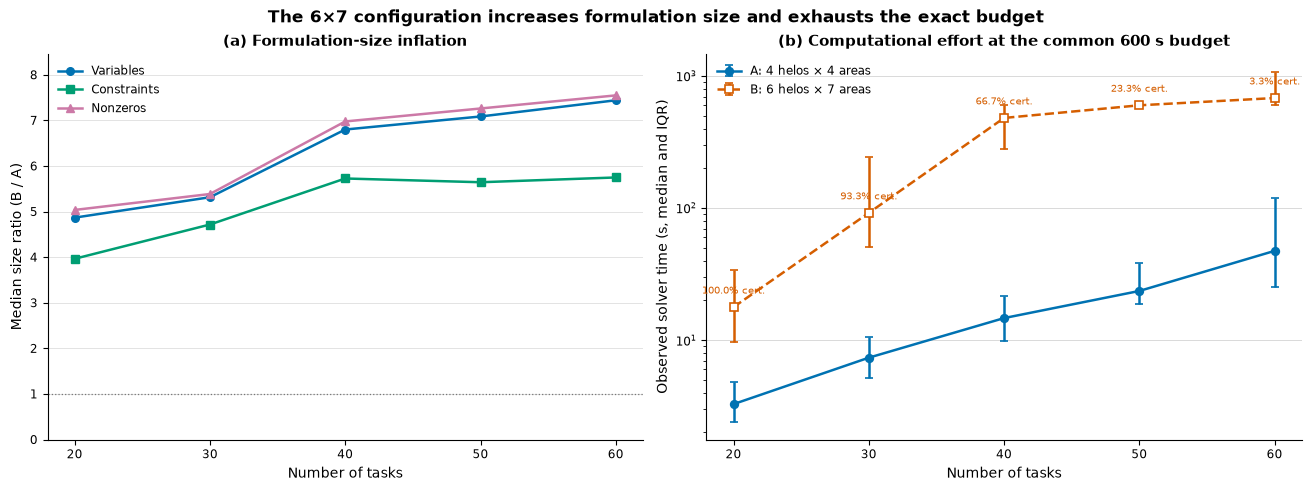

In [21]:
# ============================================================
# AB3 — COMBINED COMPUTATIONAL CONSEQUENCE OF SCALING
# (a) Model-size inflation
# (b) Observed solver time under the common 600 s budget
# ============================================================
fig, axes = plt.subplots(
    1, 2, figsize=(13.0, 4.8), constrained_layout=True
)

# Panel (a): ratios are based on medians over the same 30 seeds.
ratio_styles = {
    "Variables B/A": ("Variables", "o", "#0072B2"),
    "Constraints B/A": ("Constraints", "s", "#009E73"),
    "Nonzeros B/A": ("Nonzeros", "^", "#CC79A7"),
}
ax = axes[0]
for column, (label, marker, color) in ratio_styles.items():
    ax.plot(
        model_ratios.index,
        model_ratios[column],
        marker=marker,
        color=color,
        label=label,
    )
ax.axhline(1.0, color="#777777", linewidth=0.9, linestyle=":")
ax.set_xticks(EXPECTED_TASKS)
ax.set_xlabel("Number of tasks")
ax.set_ylabel("Median size ratio (B / A)")
ax.set_ylim(0, max(8.2, model_ratios.to_numpy().max() * 1.12))
ax.grid(True, axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.75)
ax.legend(frameon=False, loc="upper left")
ax.set_title("(a) Formulation-size inflation")

# Panel (b): both configurations use the same nominal 600 s budget.
ax = axes[1]
for configuration in CONFIG_ORDER:
    rows = runtime_600[
        runtime_600["Configuration"] == configuration
    ].sort_values("Tasks")
    median = rows["Runtime_median"].to_numpy(dtype=float)
    lower = median - rows["Runtime_Q25"].to_numpy(dtype=float)
    upper = rows["Runtime_Q75"].to_numpy(dtype=float) - median
    ax.errorbar(
        rows["Tasks"], median,
        yerr=np.vstack([lower, upper]),
        color=CONFIG_COLORS[configuration],
        marker=CONFIG_MARKERS[configuration],
        linestyle=CONFIG_LINESTYLES[configuration],
        markerfacecolor=(
            "white" if configuration == CONFIG_B
            else CONFIG_COLORS[configuration]
        ),
        markeredgewidth=1.2,
        capsize=3,
        label=configuration,
        zorder=3,
    )

    if configuration == CONFIG_B:
        for task, med, pct in zip(
            rows["Tasks"], median, rows["Certification Percent"]
        ):
            ax.annotate(
                f"{pct:.1f}% cert.",
                (task, med),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=7.3,
                color=COLOR_B,
            )

ax.set_yscale("log")
ax.set_xticks(EXPECTED_TASKS)
ax.set_xlabel("Number of tasks")
ax.set_ylabel("Observed solver time (s, median and IQR)")
ax.grid(True, which="major", axis="y", color="#D9D9D9", linewidth=0.7)
ax.legend(frameon=False, loc="upper left")
ax.set_title("(b) Computational effort at the common 600 s budget")

fig.suptitle(
    "The 6×7 configuration increases formulation size and exhausts the exact budget"
)
save_figure(fig, "AB3_model_size_and_common_budget_runtime")
plt.show()

In [22]:
# ============================================================
# 06. PAPER-READY CONCLUSION TABLE AND PROVENANCE RECORD
# ============================================================
def certification_percent(configuration, tasks, budget):
    value = certification.loc[
        (certification["Configuration"] == configuration)
        & (certification["Tasks"] == tasks)
        & (certification["Budget sec"] == float(budget)),
        "Certification Percent",
    ]
    return float(value.iloc[0]) if len(value) else np.nan


conclusion_rows = []
for tasks in EXPECTED_TASKS:
    a_600 = certification_percent(CONFIG_A, tasks, 600)
    b_600 = certification_percent(CONFIG_B, tasks, 600)
    b_1800 = certification_percent(CONFIG_B, tasks, 1800)
    conclusion_rows.append({
        "Tasks": tasks,
        "A 4x4 at 600 s (%)": a_600,
        "B 6x7 at 600 s (%)": b_600,
        "B minus A at 600 s (pp)": b_600 - a_600,
        "B 6x7 at 1800 s (%)": b_1800,
    })
conclusion_table = pd.DataFrame(conclusion_rows)

conclusion_table.to_csv(
    TABLE_DIR / "AB_paper_conclusion_table.csv", index=False
)

provenance = {
    "comparison": "joint configuration change from A 4x4 to B 6x7",
    "experiment_A_metrics": str(A_CSV),
    "experiment_B_metrics": str(B_CSV),
    "experiment_A_execution_id": sorted(
        data_a["Execution ID"].dropna().astype(str).unique().tolist()
    ),
    "experiment_B_execution_id": sorted(
        data_b["Execution ID"].dropna().astype(str).unique().tolist()
    ),
    "tasks": EXPECTED_TASKS,
    "seeds": EXPECTED_SEEDS,
    "experiment_A_budgets_sec": EXPECTED_A_BUDGETS,
    "experiment_B_budgets_sec": EXPECTED_B_BUDGETS,
    "direct_comparison_budgets_sec": COMMON_BUDGETS,
    "interpretation_boundary": (
        "The current design identifies the joint A-to-B configuration "
        "effect; it does not separately identify helicopter and area effects."
    ),
    "figures": [
        "AB1_certification_frontiers_and_budget_requirements",
        "AB2_common_budget_certification_loss_heatmap",
        "AB3_model_size_and_common_budget_runtime",
    ],
    "png_export_dpi": EXPORT_DPI,
}
with (OUTPUT_ROOT / "AB_comparison_provenance.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(provenance, file, indent=2, ensure_ascii=False)

display(conclusion_table)
print("\nMain empirical conclusion")
print(
    "At the common 600 s budget, A certifies all 30 instances at every "
    "task count, whereas B certification falls from 100.0% at 20 tasks "
    "to 3.3% at 60 tasks."
)
print(
    "Even after extending B to 1800 s, certification reaches only 90.0%, "
    "70.0%, and 30.0% for 40, 50, and 60 tasks, respectively."
)
print("\nFigures:", FIGURE_DIR)
print("Tables:", TABLE_DIR)
print("A–B comparison notebook completed successfully.")

,Tasks,A 4x4 at 600 s (%),B 6x7 at 600 s (%),B minus A at 600 s (pp),B 6x7 at 1800 s (%)
0,20,100.0,100.000000,0.000000,100.0
1,30,100.0,93.333333,-6.666667,100.0
2,40,100.0,66.666667,-33.333333,90.0
3,50,100.0,23.333333,-76.666667,70.0
4,60,100.0,3.333333,-96.666667,30.0



Main empirical conclusion
At the common 600 s budget, A certifies all 30 instances at every task count, whereas B certification falls from 100.0% at 20 tasks to 3.3% at 60 tasks.
Even after extending B to 1800 s, certification reaches only 90.0%, 70.0%, and 30.0% for 40, 50, and 60 tasks, respectively.

Figures: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/figures
Tables: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/tables
A–B comparison notebook completed successfully.


PNG saved at: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/figures/AB4_effect_of_extending_B_budget_to_1800s.png
PDF saved at: /Users/educarrascovidal/Documentos/GitHub/Tesis_Doctoral/DISC_TESIS/Resuelto_Paper/ttap_comparison_A4x4_B6x7/figures/AB4_effect_of_extending_B_budget_to_1800s.pdf


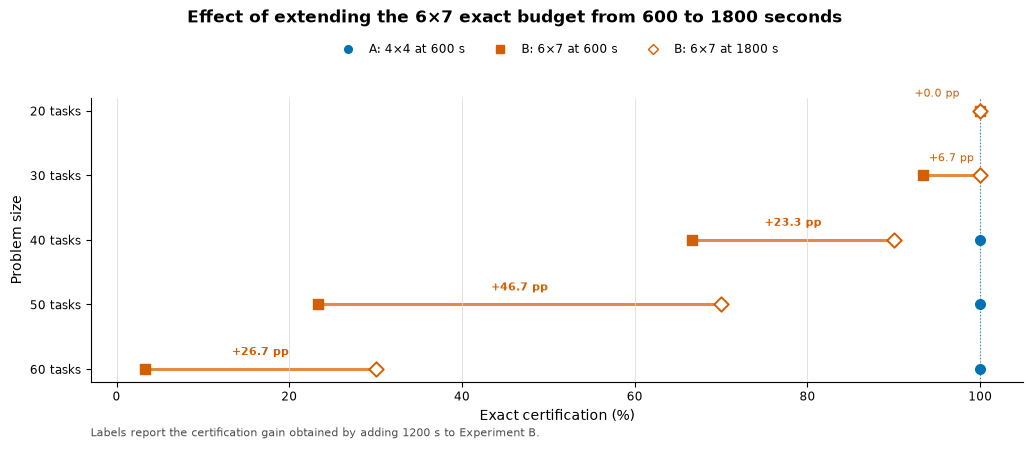

,Tasks,A at 600 s (%),B at 600 s (%),B at 1800 s (%),Gain from 600 to 1800 s (pp),Remaining gap to A at 600 s (pp)
0,20,100.0,100.000000,100.0,0.000000,0.0
1,30,100.0,93.333333,100.0,6.666667,0.0
2,40,100.0,66.666667,90.0,23.333333,10.0
3,50,100.0,23.333333,70.0,46.666667,30.0
4,60,100.0,3.333333,30.0,26.666667,70.0


In [23]:
# ============================================================
# AB4 — VALUE OF EXTENDING B FROM 600 TO 1800 SECONDS
# ============================================================
def certification_pct(configuration, tasks, budget):
    return float(
        certification.loc[
            (certification["Configuration"] == configuration)
            & (certification["Tasks"] == tasks)
            & (certification["Budget sec"] == budget),
            "Certification Percent",
        ].iloc[0]
    )


rows = []

for tasks in EXPECTED_TASKS:
    a_600 = certification_pct(CONFIG_A, tasks, 600)
    b_600 = certification_pct(CONFIG_B, tasks, 600)
    b_1800 = certification_pct(CONFIG_B, tasks, 1800)

    rows.append({
        "Tasks": tasks,
        "A at 600 s (%)": a_600,
        "B at 600 s (%)": b_600,
        "B at 1800 s (%)": b_1800,
        "Gain from 600 to 1800 s (pp)": b_1800 - b_600,
        "Remaining gap to A at 600 s (pp)": a_600 - b_1800,
    })

budget_extension = pd.DataFrame(rows)

budget_extension.to_csv(
    TABLE_DIR / "AB4_budget_extension_summary.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(10.6, 4.9), constrained_layout=False)
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.78)

y_positions = np.arange(len(EXPECTED_TASKS))

for y, row in zip(y_positions, budget_extension.to_dict("records")):
    b_600 = row["B at 600 s (%)"]
    b_1800 = row["B at 1800 s (%)"]
    gain = row["Gain from 600 to 1800 s (pp)"]

    # Improvement obtained by extending B
    ax.plot(
        [b_600, b_1800],
        [y, y],
        color=COLOR_B,
        linewidth=2.2,
        alpha=0.72,
        zorder=1,
    )

    # B at 600 seconds
    ax.scatter(
        b_600,
        y,
        marker="s",
        s=52,
        facecolor=COLOR_B,
        edgecolor=COLOR_B,
        zorder=3,
    )

    # B at 1800 seconds
    ax.scatter(
        b_1800,
        y,
        marker="D",
        s=54,
        facecolor="white",
        edgecolor=COLOR_B,
        linewidth=1.4,
        zorder=4,
    )

    # A benchmark at 600 seconds
    ax.scatter(
        row["A at 600 s (%)"],
        y,
        marker="o",
        s=48,
        facecolor=COLOR_A,
        edgecolor=COLOR_A,
        zorder=2,
    )

    label_x = (b_600 + b_1800) / 2

    if np.isclose(gain, 0):
        label_x = max(2.5, b_600 - 5)

    ax.annotate(
        f"+{gain:.1f} pp",
        (label_x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.2,
        color=COLOR_B,
        fontweight="semibold" if gain >= 20 else "normal",
    )

ax.axvline(
    100,
    color=COLOR_A,
    linewidth=0.9,
    linestyle=":",
    alpha=0.75,
)

ax.set_xlim(-3, 105)
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_yticks(y_positions)
ax.set_yticklabels([f"{tasks} tasks" for tasks in EXPECTED_TASKS])
ax.invert_yaxis()

ax.set_xlabel("Exact certification (%)")
ax.set_ylabel("Problem size")
ax.grid(
    True,
    axis="x",
    color="#D9D9D9",
    linewidth=0.7,
    alpha=0.75,
)

fig.suptitle(
    "Effect of extending the 6×7 exact budget from 600 to 1800 seconds",
    y=0.96,
)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=COLOR_A,
        markeredgecolor=COLOR_A,
        label="A: 4×4 at 600 s",
    ),
    Line2D(
        [0], [0],
        marker="s",
        linestyle="none",
        markerfacecolor=COLOR_B,
        markeredgecolor=COLOR_B,
        label="B: 6×7 at 600 s",
    ),
    Line2D(
        [0], [0],
        marker="D",
        linestyle="none",
        markerfacecolor="white",
        markeredgecolor=COLOR_B,
        label="B: 6×7 at 1800 s",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.11),
    ncol=3,
    frameon=False,
)

ax.text(
    0,
    -0.16,
    "Labels report the certification gain obtained by adding "
    "1200 s to Experiment B.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.2,
    color=COLOR_NEUTRAL,
)

save_figure(
    fig,
    "AB4_effect_of_extending_B_budget_to_1800s",
)

plt.show()
display(budget_extension)

## Methodological conclusion

The paired task-profile structure and common budgets support a direct comparison of the two experimental configurations. The results show a progressively stronger rightward shift in the certification frontier as the number of tasks increases. This is evidence of the **joint computational impact of scaling from 4×4 to 6×7**.

A separate causal attribution to helicopters and demand areas would require the intermediate configurations 4×7 and 6×4 under the same task profiles, seeds, and budgets.